# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:**
**Student ID:**
**Section:**
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [4]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df = pd.read_csv('numeric_churn.csv')
y = df["Churn"]
X = df.drop(columns=["Churn"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
print(f"X shape: {X.shape}")
print(f"Non numeric columns: {len(X.select_dtypes(exclude=["number"]).columns)}")
print(f"Missing values count: {X.isnull().sum().sum()}")
print(f"Target distribution in y: {y.value_counts(normalize=True)}")

X shape: (7032, 22)
Non numeric columns: 0
Missing values count: 0
Target distribution in y: Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [6]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics
best_tree = DecisionTreeClassifier(max_depth = 4, random_state = 42)
#best_tree.fit(X, y)
best_tree.fit(X_train, y_train)

y_pred = best_tree.predict(X_test)

acc_best = accuracy_score(y_test, y_pred)
recall_best = recall_score(y_test, y_pred)
precision_best = precision_score(y_test, y_pred)
f1_best = f1_score(y_test, y_pred)

print("Metrics at max depth 4:")
print(f"Accuracy:  {acc_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1 Score:  {f1_best:.4f}")

Metrics at max depth 4:
Accuracy:  0.7832
Precision: 0.6131
Recall:    0.5000
F1 Score:  0.5508


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7832|
| Precision | 0.6131|
| Recall | 0.5000|
| F1-score | 0.5508|

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [7]:
# Task 3 — train Random Forest, predict on test set
# n_estimate means number of trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("done")

done


**Answer 4:**
A Random Forest can generalize better than a single Decision Tree because it combines predictions from many different trees instead of relying on only one tree. This makes the model more robust and can reduce the effect of overfitting from an individual tree.

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Metrics for Random Forest:
Accuracy:  0.7854
Recall: 0.5027
Precision: 0.6184
F1 Score: 0.5546


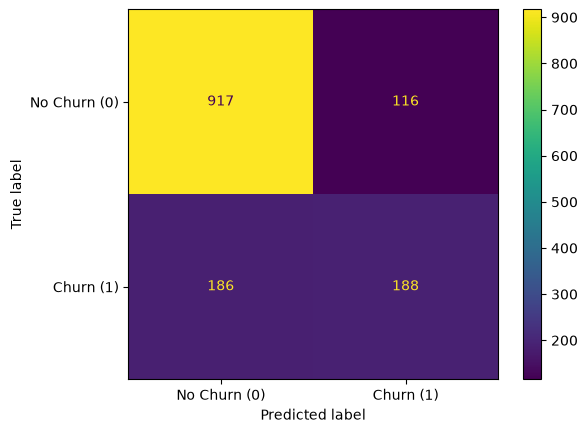

In [8]:
# Task 5 — Random Forest metrics + confusion matrix
rf_y_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print("Metrics for Random Forest:")
print(f"Accuracy:  {rf_acc:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"F1 Score: {rf_f1:.4f}")

cf = confusion_matrix(y_test, rf_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot()
plt.show()

**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.7854 |
| Precision |0.5027|
| Recall | 0.6184|
| F1-score |0.5546 |

**Observation (confusion matrix):**

The confusion matrix shows that the Random Forest correctly classifies most customers who do not churn, but it misses a noticeable number of customers who actually churn. This is reflected in the recall of about 0.5027, meaning the model identifies only about half of the actual churn cases. Therefore, although the overall accuracy is 78.54%, there is still room for improvement in detecting churn customers.

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy |0.7832 | 0.7854|
| Precision | 0.6130|0.5027 |
| Recall |0.5000 |0.6164 |
| F1-score |0.5508 |0.5546 |

**Answer 7:**
The Random Forest performs slightly better than the Decision Tree on all four evaluation metrics. Its accuracy, precision, recall, and F1-score are all marginally higher. However, the differences are very small, so the improvement over the Decision Tree is marginal rather than substantial. Since the dataset contains a class imbalance, F1-score and recall are important for evaluating how well the models identify customers who churn.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [ ]:
# Task 8 — 5-fold cross-validation for both models

# Decision Tree cross-validation
dt_cv_scores = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='f1')
print("Decision Tree F1 scores for each fold:")
print(dt_cv_scores)
print("Decision Tree Mean F1 Score:", dt_cv_scores.mean())
print("Decision Tree F1 Standard Deviation:", dt_cv_scores.std())
print("-" * 40)

# Random Forest cross-validation
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

print("Random Forest F1 scores for each fold:")
print(rf_cv_scores)
print("Random Forest Mean F1 Score:", rf_cv_scores.mean())
print("Random Forest F1 Standard Deviation:", rf_cv_scores.std())

Decision Tree F1 scores for each fold:
[0.55045872 0.5483871  0.5526839  0.47058824 0.53030303]
Decision Tree Mean F1 Score: 0.53048419491759
Decision Tree F1 Standard Deviation: 0.030983482460030673
----------------------------------------
Random Forest F1 scores for each fold:
[0.53731343 0.57743786 0.55185185 0.52532833 0.56877323]
Random Forest Mean F1 Score: 0.5521409415206799
Random Forest F1 Standard Deviation: 0.019263550456845687


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree |0.53048419491759 |0.030983482460030673 |
| Random Forest | 0.5521409415206799 |  0.019263550456845687|

**Answer 9:**
Comparison to Single Split: On the single test split, both models had close performance (Decision Tree F1: ~0.5508 vs. Random Forest F1: ~0.5546). However, the 5-fold cross-validation shows that the Decision Tree averages a lower F1-score (0.5305) with higher variance (std: 0.0310), whereas the Random Forest achieves a higher average F1-score (0.5521) with lower variance (std: 0.0193).

Impact on Conclusion: The cross-validation results increase confidence in choosing Random Forest. Even though their single test set metrics appeared very similar, Random Forest demonstrates superior stability across multiple splits and handles dataset variance better than a single Decision Tree.

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [15]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 8, 12],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best 5-Fold Cross-Validation F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 50}
Best 5-Fold Cross-Validation F1 Score: 0.5710231525235233


**Answer 11 (best hyperparameters & CV score):**
Best Hyperparameters: {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 50}

Best Cross-Validated F1 Score: 0.5710

In [16]:
# Task 12 — evaluate the tuned model on the test set

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Test Metrics:")
print("Accuracy :", tuned_acc)
print("Precision:", tuned_prec)
print("Recall   :", tuned_rec)
print("F1-score :", tuned_f1)

Tuned Random Forest Test Metrics:
Accuracy : 0.7960199004975125
Precision: 0.639871382636656
Recall   : 0.5320855614973262
F1-score : 0.581021897810219


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7960199004975125 |
| Precision | 0.639871382636656|
| Recall |  0.5320855614973262|
| F1-score | 0.581021897810219 |

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy | 0.7832| 0.7854| 0.7960|
| Precision |0.6131 |0.6184 |0.6399 |
| Recall | 0.5000|0.5000 |0.5321 |
| F1-score |0.5508 |0.5546 |0.5810 |

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

In [12]:
# Task 14 — extract and visualize feature importances


**Answer 14:**
_(your answer here)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
_(your answer here)_

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [13]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
_(your answer here)_

**Answer 18 — Next steps:**
_(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted